In [2]:
import sys, os
import importlib.util as imp
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

In [3]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

In [4]:
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
spec_win = imp.spec_from_file_location("lumapi", lumapiFile)
lumapi = imp.module_from_spec(spec_win)
spec_win.loader.exec_module(lumapi)
emeApi = lumapi.MODE(hide = False)

In [5]:
um = 1e-6
nm = 1e-9

In [6]:
n_c = 1.444
n_r = 3.476
lambda_0 = 1550*nm
Wm = 7*um
k_0 = 2*np.pi/lambda_0
N = 2



In [7]:
sigma = 0
We = Wm + (lambda_0/ np.pi) * (n_c/n_r)**(2*sigma) * (n_r**2 - n_c**2)**(-1/2)
We/um

7.1560405319904525

In [8]:
neff_app = np.zeros(6)
for i in range (6):
    neff_app[i] = n_r - ((i+1)**2 * np.pi * lambda_0)/(We**2 * 4 * n_r * k_0)
    kc = (i+1)* np.pi / We
    print("neff_app = %4.5f" %neff_app[i])

neff_app = 3.47431
neff_app = 3.46925
neff_app = 3.46082
neff_app = 3.44901
neff_app = 3.43382
neff_app = 3.41526


In [9]:
Lpi = 2*np.pi / (neff_app[0] - neff_app[2])/k_0
Lpi/um
#Lpi2 = (4*n_r*We**2)/(3*lambda_0)
#Lpi2/um

np.float64(114.84012409543644)

In [ ]:
L = 3*Lpi/N
#L = 0.5*Lpi
L/um
#L = L/4

np.float64(0.00011484012409543642)

In [11]:
# PARAMETERS 
taper_heigth = 15*um
taper_width = 1.5*um

wg_width = 450*nm
wg_heigth = 220*nm

x_span_rect = 4*um

x_taper = L/2 + taper_heigth/2
#y_taper = We/6
y_taper = (Wm/2-taper_width)+(taper_width/2)

lambda_start = 1.53*um
lambda_stop = 1.57*um
num_points = 100

material_wg = "Si (Silicon) - Palik"
material_background = "SiO2 (Glass) - Palik"

filename = "S_MMI_EME_2x2_%d_um" %(L/um)


In [12]:
emeApi.addstructuregroup()
dev_layer = "GDS_LAYER_35:4"
emeApi.set("name", dev_layer)

Criação do dispositivo

In [13]:
# Criação do dispositivo

# caixa central
emeApi.addrect()
emeApi.addtogroup(dev_layer)
emeApi.set("name", "box")
emeApi.set("x", 0)
emeApi.set("y", 0)
emeApi.set("z", wg_heigth/2)
emeApi.set("x span", L)
emeApi.set("y span",Wm)
emeApi.set("z span", wg_heigth)
emeApi.set("material", material_wg)


#tapers
emeApi.addobject("linear_taper")
emeApi.set("name", "taper1")
emeApi.set("angle_side", 90)
emeApi.set("width_r", taper_width)
emeApi.set("width_l", wg_width)
emeApi.set("len", taper_heigth)
emeApi.set("material", material_wg)
emeApi.set("thickness", wg_heigth)
emeApi.set("x", -x_taper)
emeApi.set("y", y_taper)
emeApi.set("z", wg_heigth/2)

emeApi.copy()
emeApi.set("name", "taper2")
emeApi.set("y", -y_taper)

emeApi.copy()
emeApi.set("name", "taper3")
emeApi.set("y", y_taper)
emeApi.set("width_l", taper_width)
emeApi.set("width_r", wg_width)
emeApi.set("x", x_taper)

emeApi.copy()
emeApi.set("name", "taper4")
emeApi.set("y", -y_taper)

# guias monomodos
emeApi.addrect()
emeApi.addtogroup(dev_layer)
emeApi.set("name", "rect_port1")
emeApi.set("x", -(x_taper + taper_heigth/2 + x_span_rect/2))
emeApi.set("y", y_taper)
emeApi.set("z", wg_heigth/2)
emeApi.set("x span", x_span_rect)
emeApi.set("y span", wg_width)
emeApi.set("z span", wg_heigth)
emeApi.set("material", material_wg)

emeApi.copy()
emeApi.set("name", "rect_port2")
emeApi.set("y", -y_taper)

emeApi.copy()
emeApi.set("name", "rect_port3")
emeApi.set("y", y_taper)
emeApi.set("x", (x_taper + taper_heigth/2 + x_span_rect/2))

emeApi.copy()
emeApi.set("name", "rect_port4")
emeApi.set("y", -y_taper)






In [14]:
# add solver
emeApi.addeme()

bound_x_offset = 0.5*um
bound_y_offset = 2*um
bound_z_offset = 0.5*um

port_y_span = 2*um
port_z_span = 2*um

emeApi.set("x", 0)
emeApi.set("y", 0)
emeApi.set("z", wg_heigth/2)
emeApi.set("x min", -(L/2+taper_heigth+x_span_rect - bound_x_offset))
emeApi.set("y span", Wm+2*bound_y_offset)
emeApi.set("z span", wg_heigth/2 + 2*bound_z_offset)
emeApi.set("background material", material_background)

In [15]:
cell_wg = 1
cell_taper = 16
cell_box = 1

span_wg = x_span_rect-bound_x_offset
span_taper = taper_heigth
span_box = L

method_wg = 0
method_taper = 1
method_box = 0

modes_wg = 4
modes_taper = 10
modes_box = 32

emeApi.set("number of cell groups", 5)
emeApi.set("group spans", np.block([[span_wg], [span_taper], [span_box], [span_taper], [span_wg]]))
emeApi.set("cells",  np.block([[cell_wg], [cell_taper], [cell_box], [cell_taper], [cell_wg]]))
emeApi.set("subcell method",  np.block([[method_wg], [method_taper], [method_box], [method_taper], [method_wg]]))
emeApi.set("allow custom eigensolver settings", True)
emeApi.set("modes", np.block([[modes_wg], [modes_taper], [modes_box], [modes_taper], [modes_wg]]))
emeApi.set("display cells", 1)

emeApi.set("mesh cells y", 200)
emeApi.set("mesh cells z", 200)

emeApi.set("y min bc", "PML")
emeApi.set("y max bc", "PML")
emeApi.set("z min bc", "Symmetric")
emeApi.set("z max bc", "PML")

In [16]:
#portas
emeApi.select("EME::Ports::port_1")
emeApi.set("use full simulation span", 0)
emeApi.set("y", y_taper)
emeApi.set("y span", port_y_span)
emeApi.set("z", 0)
emeApi.set("z span", port_z_span)
emeApi.set("mode selection", "fundamental TE mode")

emeApi.select("EME::Ports::port_2")
emeApi.set("use full simulation span", 0)
emeApi.set("port location", "left")
emeApi.set("y", -y_taper)
emeApi.set("y span", port_y_span)
emeApi.set("z", 0)
emeApi.set("z span", port_z_span)
emeApi.set("mode selection", "fundamental TE mode")

emeApi.addemeport()
emeApi.set("use full simulation span", 0)
emeApi.set("port location", "right")
emeApi.set("y", y_taper)
emeApi.set("y span", port_y_span)
emeApi.set("z", 0)
emeApi.set("z span", port_z_span)
emeApi.set("mode selection", "fundamental TE mode")

emeApi.addemeport()
emeApi.set("use full simulation span", 0)
emeApi.set("port location", "right")
emeApi.set("y", -y_taper)
emeApi.set("y span", port_y_span)
emeApi.set("z", 0)
emeApi.set("z span", port_z_span)
emeApi.set("mode selection", "fundamental TE mode")



In [17]:
# monitor
emeApi.addemeprofile()
emeApi.set("name", "profile")
emeApi.set("monitor type", 3)
emeApi.set("x", 0)
emeApi.set("y", 0)
emeApi.set("z", wg_heigth/2)
emeApi.set("x span", emeApi.getnamed("EME", "x span"))
emeApi.set("y span", Wm+2*bound_y_offset)
emeApi.set("z", wg_heigth/2)



In [18]:
# mesh
emeApi.addmesh()
emeApi.set("x", -x_taper)
emeApi.set("y", y_taper)
emeApi.set("z", wg_heigth/2)
emeApi.set("name", "mesh1")
emeApi.set("x span", span_taper)
emeApi.set("y span", taper_width)
emeApi.set("z span", wg_heigth/2)
emeApi.set("set mesh multiplier", True)
emeApi.set("x mesh multiplier", 4)
emeApi.set("y mesh multiplier", 4)
emeApi.set("z mesh multiplier", 4)


emeApi.copy()
emeApi.set("name", "mesh2")
emeApi.set("y", -y_taper)


emeApi.copy()
emeApi.set("name", "mesh3")
emeApi.set("x", x_taper)
emeApi.set("y", y_taper)


emeApi.copy()
emeApi.set("name", "mesh4")
emeApi.set("x", x_taper)
emeApi.set("y", -y_taper)


In [19]:
emeApi.save(filename)

In [20]:
emeApi.run()

In [21]:
emeApi.emepropagate()

In [22]:
E = emeApi.getresult("profile", "field profile")

x = E["x"]
x = x[:,0]/um

y = E["y"]
y = y[:,0]/um

z = E["z"]
E = E["E"]

Ex = E[:,:,0,:,0]
Ey = E[:,:,0,:,1]
Ez = E[:,:,0,:,2]

Emag = np.sqrt(np.abs(Ex)**2 + np.abs(Ey)**2 + Ez**2)

c:\Users\Isa Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
c:\Users\Isa Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
c:\Users\Isa Cristina\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\ma\core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


<function matplotlib.pyplot.show(close=None, block=None)>

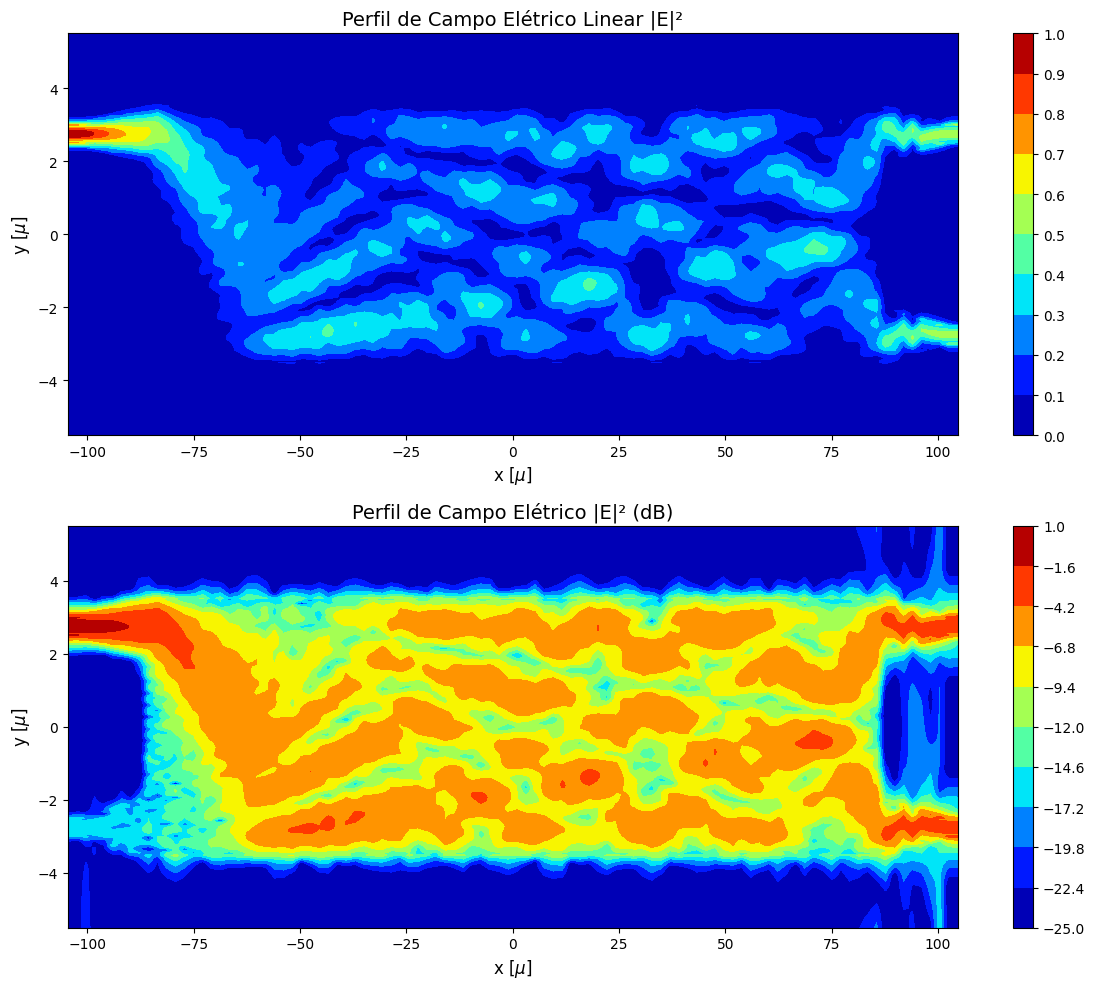

In [23]:
fig,axs = plt.subplots(2,1,figsize= (12,10))


mycmap1 = plt.get_cmap("jet")

v1 = np.linspace(0,1,11, endpoint=True)

cp1 = axs[0].contourf(x, y, np.clip(np.transpose(Emag[:,:,0]), v1.min(), v1.max()), v1, cmap = mycmap1)
plt.colorbar(cp1, ax=axs[0], ticks=v1)

axs[0].set_xlabel(r"x [$\mu$]", fontsize=12)
axs[0].set_ylabel(r"y [$\mu$]", fontsize=12)
axs[0].set_title("Perfil de Campo Elétrico Linear |E|²", fontsize = 14)

mycmap2 = plt.get_cmap("jet")

v2 = np.linspace(-25,1,11, endpoint=True)

cp2 = axs[1].contourf(x, y, np.clip(10*np.log10(np.transpose(Emag[:,:,0])), v2.min(), v2.max()), v2, cmap = mycmap2)
plt.colorbar(cp2, ax=axs[1], ticks=v2)

axs[1].set_xlabel(r"x [$\mu$]", fontsize=12)
axs[1].set_ylabel(r"y [$\mu$]", fontsize=12)
axs[1].set_title("Perfil de Campo Elétrico |E|² (dB)", fontsize = 14)

plt.tight_layout()
plt.savefig("2 Perfil de campo - EME.png")
plt.show



In [24]:
emeApi.setemeanalysis("propagation sweep", 1)
emeApi.setemeanalysis("parameter", "group span 3")
emeApi.setemeanalysis("start", 0.9*span_box)
emeApi.setemeanalysis("stop", 1.1*span_box)
emeApi.setemeanalysis("number of points", num_points)

In [25]:
emeApi.emesweep("propagation sweep")

In [26]:
S = emeApi.getemesweep("S")
group_span = S["group_span_3"]

T1 = np.abs(S["s11"])**2
T2 = np.abs(S["s21"])**2
T3 = np.abs(S["s31"])**2
T4 = np.abs(S["s41"])**2

T1_dB = 10*np.log10(T1)
T2_dB = 10*np.log10(T2)
T3_dB = 10*np.log10(T3)
T4_dB = 10*np.log10(T4)

<function matplotlib.pyplot.show(close=None, block=None)>

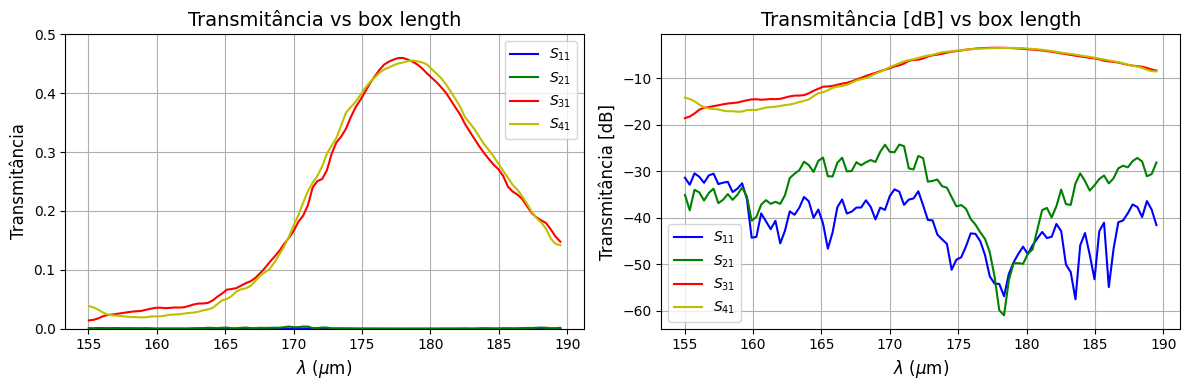

In [27]:
fig1,axs1 = plt.subplots(1,2,figsize= (12,4))

axs1[0].plot(group_span/um, T1, "b", lw = 1.5, label = "$S_{11}$")
axs1[0].plot(group_span/um, T2, "g", lw = 1.5, label = "$S_{21}$")
axs1[0].plot(group_span/um, T3, "r", lw = 1.5, label = "$S_{31}$")
axs1[0].plot(group_span/um, T4, "y", lw = 1.5, label = "$S_{41}$")
axs1[0].set_xlabel(r"$\lambda$ ($\mu$m)", fontsize = 12)
axs1[0].set_ylabel(r"Transmitância", fontsize = 12)
axs1[0].set_title(r"Transmitância vs box length", fontsize = 14)
axs1[0].set_ylim(0.0, 0.5)
#axs1[0].set_xlim(175, 180)
axs1[0].grid()
axs1[0].legend()

axs1[1].plot(group_span/um, T1_dB, "b", lw = 1.5, label = "$S_{11}$")
axs1[1].plot(group_span/um, T2_dB, "g", lw = 1.5, label = "$S_{21}$")
axs1[1].plot(group_span/um, T3_dB, "r", lw = 1.5, label = "$S_{31}$")
axs1[1].plot(group_span/um, T4_dB, "y", lw = 1.5, label = "$S_{41}$")
axs1[1].set_xlabel(r"$\lambda$ ($\mu$m)", fontsize = 12)
axs1[1].set_ylabel(r"Transmitância [dB]", fontsize = 12)
axs1[1].set_title(r"Transmitância [dB] vs box length", fontsize = 14)
#axs1[1].set_ylim(-6, 0)
#axs1[1].set_xlim(175, 180)
axs1[1].grid()
axs1[1].legend()

plt.tight_layout()
plt.savefig("2 Transmissao vs box length - EME.png")
plt.show


In [28]:
#emeApi.setemeanalysis("group spans", np.block([[span_wg], [span_taper], [span_box], [span_taper], [span_wg]]))
#emeApi.getemeanalysis("group spans")

In [29]:
emeApi.setemeanalysis("wavelength sweep", 1)
emeApi.setemeanalysis("start wavelength", lambda_start)
emeApi.setemeanalysis("stop wavelength", lambda_stop)
emeApi.setemeanalysis("number of wavelength points", num_points)
emeApi.setemeanalysis("calculate group delays", 1)

In [30]:
emeApi.emesweep("wavelength sweep")

In [31]:
S = emeApi.getemesweep("S_wavelength_sweep")
Lambda = S["wavelength"]

T1 = np.abs(S["s11"])**2
T2 = np.abs(S["s21"])**2
T3 = np.abs(S["s31"])**2
T4 = np.abs(S["s41"])**2

T1_dB = 10*np.log10(T1)
T2_dB = 10*np.log10(T2)
T3_dB = 10*np.log10(T3)
T4_dB = 10*np.log10(T4)

<function matplotlib.pyplot.show(close=None, block=None)>

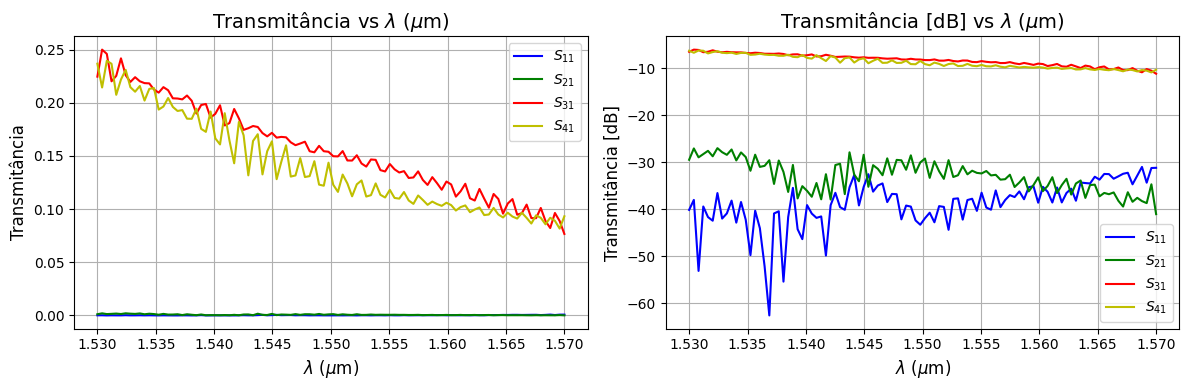

In [32]:
fig2,axs2 = plt.subplots(1,2,figsize= (12,4))

axs2[0].plot(Lambda/um, T1, "b", lw = 1.5, label = "$S_{11}$")
axs2[0].plot(Lambda/um, T2, "g", lw = 1.5, label = "$S_{21}$")
axs2[0].plot(Lambda/um, T3, "r", lw = 1.5, label = "$S_{31}$")
axs2[0].plot(Lambda/um, T4, "y", lw = 1.5, label = "$S_{41}$")
axs2[0].set_xlabel(r"$\lambda$ ($\mu$m)", fontsize = 12)
axs2[0].set_ylabel(r"Transmitância", fontsize = 12)
axs2[0].set_title(r"Transmitância vs $\lambda$ ($\mu$m)", fontsize = 14)
#axs2[0].set_ylim(0.0, 0.5)
#axs2[0].set_xlim(170, 185)
axs2[0].grid()
axs2[0].legend()

axs2[1].plot(Lambda/um, T1_dB, "b", lw = 1.5, label = "$S_{11}$")
axs2[1].plot(Lambda/um, T2_dB, "g", lw = 1.5, label = "$S_{21}$")
axs2[1].plot(Lambda/um, T3_dB, "r", lw = 1.5, label = "$S_{31}$")
axs2[1].plot(Lambda/um, T4_dB, "y", lw = 1.5, label = "$S_{41}$")
axs2[1].set_xlabel(r"$\lambda$ ($\mu$m)", fontsize = 12)
axs2[1].set_ylabel(r"Transmitância [dB]", fontsize = 12)
axs2[1].set_title(r"Transmitância [dB] vs $\lambda$ ($\mu$m)", fontsize = 14)
#axs2[1].set_ylim(-6, 0)
#axs2[1].set_xlim(170, 185)
axs2[1].grid()
axs2[1].legend()

plt.tight_layout()
plt.savefig("2 Transmissao vs wavelength - EME.png")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

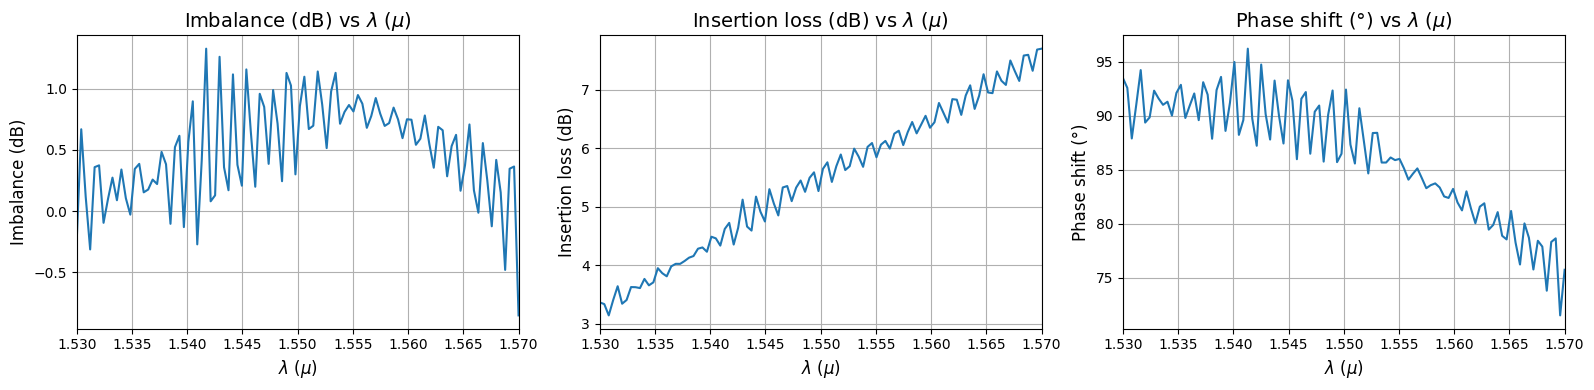

In [33]:
fig3, axs3 = plt.subplots(1,3, figsize = (16,4))

Ib = T3_dB - T4_dB

axs3[0].plot(Lambda/um, Ib, lw = 1.5)
axs3[0].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[0].set_ylabel(r"Imbalance (dB)", fontsize = 12)
axs3[0].set_title(r"Imbalance (dB) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[0].set_xlim(1.53, 1.57)
axs3[0].grid()

Il = -10*np.log10(T3+T4)
axs3[1].plot(Lambda/um, Il, lw=1.5)
axs3[1].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[1].set_ylabel(r"Insertion loss (dB)", fontsize = 12)
axs3[1].set_title(r"Insertion loss (dB) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[1].set_xlim(1.53, 1.57)
axs3[1].grid()

phi1 = np.angle(S["s31"])
phi2 = np.angle(S["s41"])

phase = (phi1-phi2)*(180/np.pi)

for p in range (len(phase)):
    if (np.abs(phase[p]))>180:
        phase[p] = phase[p] + 360
    



axs3[2].plot(Lambda/um,phase, lw=1.5)
axs3[2].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[2].set_ylabel(r"Phase shift (°)", fontsize = 12)
axs3[2].set_title(r"Phase shift (°) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[2].set_xlim(1.53, 1.57)
axs3[2].grid()

plt.tight_layout()
plt.savefig("2 Perdas - EME.png")
plt.show

In [34]:
emeApi.setemeanalysis("group spans", np.block([[span_wg], [span_taper], [177.5*um], [span_taper], [span_wg]]))
emeApi.getemeanalysis("group spans")

array([[3.500e-06],
       [1.500e-05],
       [1.775e-04],
       [1.500e-05],
       [3.500e-06]])

In [35]:
emeApi.setemeanalysis("wavelength sweep", 1)
emeApi.setemeanalysis("start wavelength", lambda_start)
emeApi.setemeanalysis("stop wavelength", lambda_stop)
emeApi.setemeanalysis("number of wavelength points", num_points)
emeApi.setemeanalysis("calculate group delays", 1)

In [36]:
emeApi.emesweep("wavelength sweep")

In [37]:
S = emeApi.getemesweep("S_wavelength_sweep")
Lambda = S["wavelength"]

T1 = np.abs(S["s11"])**2
T2 = np.abs(S["s21"])**2
T3 = np.abs(S["s31"])**2
T4 = np.abs(S["s41"])**2

T1_dB = 10*np.log10(T1)
T2_dB = 10*np.log10(T2)
T3_dB = 10*np.log10(T3)
T4_dB = 10*np.log10(T4)

<function matplotlib.pyplot.show(close=None, block=None)>

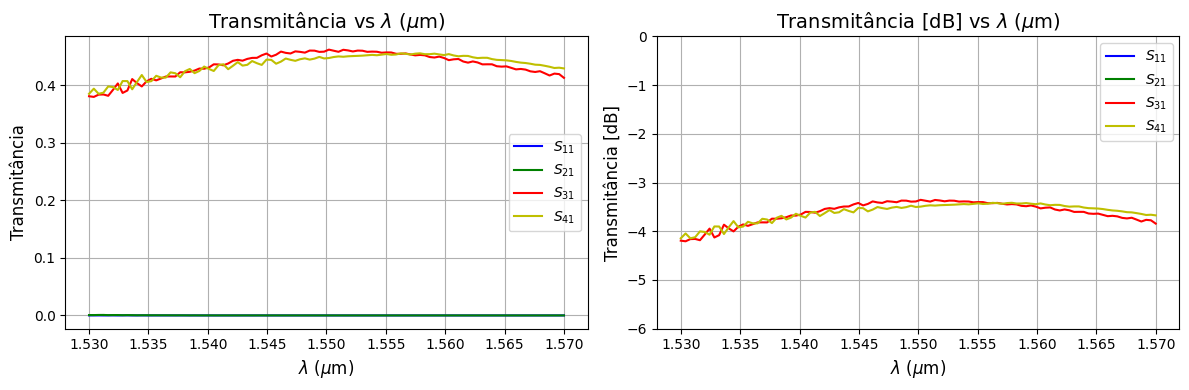

In [38]:
fig2,axs2 = plt.subplots(1,2,figsize= (12,4))

axs2[0].plot(Lambda/um, T1, "b", lw = 1.5, label = "$S_{11}$")
axs2[0].plot(Lambda/um, T2, "g", lw = 1.5, label = "$S_{21}$")
axs2[0].plot(Lambda/um, T3, "r", lw = 1.5, label = "$S_{31}$")
axs2[0].plot(Lambda/um, T4, "y", lw = 1.5, label = "$S_{41}$")
axs2[0].set_xlabel(r"$\lambda$ ($\mu$m)", fontsize = 12)
axs2[0].set_ylabel(r"Transmitância", fontsize = 12)
axs2[0].set_title(r"Transmitância vs $\lambda$ ($\mu$m)", fontsize = 14)
#axs2[0].set_ylim(0.0, 0.5)
#axs2[0].set_xlim(170, 185)
axs2[0].grid()
axs2[0].legend()

axs2[1].plot(Lambda/um, T1_dB, "b", lw = 1.5, label = "$S_{11}$")
axs2[1].plot(Lambda/um, T2_dB, "g", lw = 1.5, label = "$S_{21}$")
axs2[1].plot(Lambda/um, T3_dB, "r", lw = 1.5, label = "$S_{31}$")
axs2[1].plot(Lambda/um, T4_dB, "y", lw = 1.5, label = "$S_{41}$")
axs2[1].set_xlabel(r"$\lambda$ ($\mu$m)", fontsize = 12)
axs2[1].set_ylabel(r"Transmitância [dB]", fontsize = 12)
axs2[1].set_title(r"Transmitância [dB] vs $\lambda$ ($\mu$m)", fontsize = 14)
axs2[1].set_ylim(-6, 0)
#axs2[1].set_xlim(170, 185)
axs2[1].grid()
axs2[1].legend()

plt.tight_layout()
plt.savefig("2 Transmissao vs wavelength - otmizado - EME.png")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

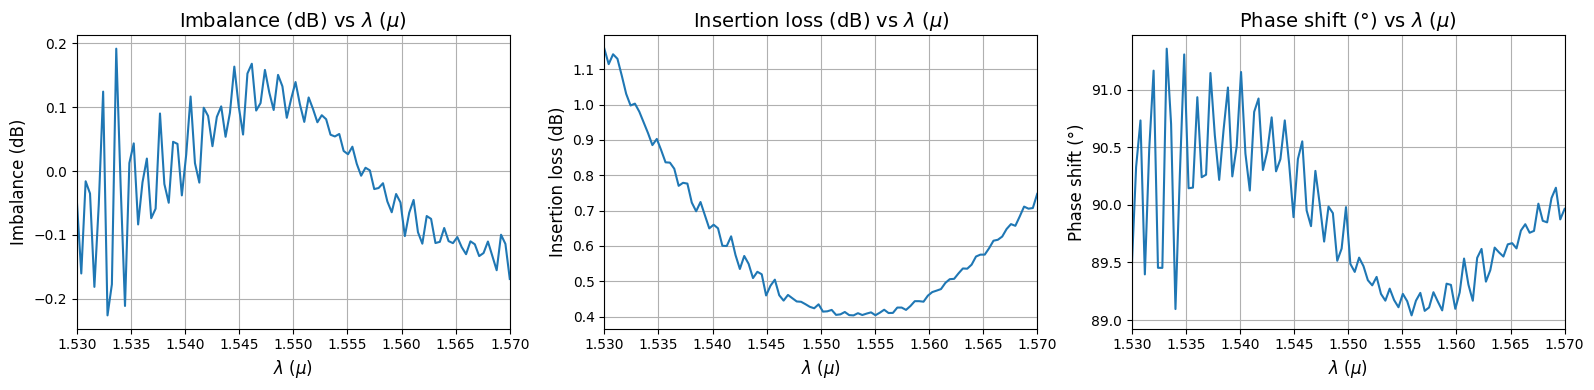

In [39]:
fig3, axs3 = plt.subplots(1,3, figsize = (16,4))

Ib = T3_dB - T4_dB

axs3[0].plot(Lambda/um, Ib, lw = 1.5)
axs3[0].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[0].set_ylabel(r"Imbalance (dB)", fontsize = 12)
axs3[0].set_title(r"Imbalance (dB) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[0].set_xlim(1.53, 1.57)
axs3[0].grid()

Il = -10*np.log10(T3+T4)
axs3[1].plot(Lambda/um, Il, lw=1.5)
axs3[1].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[1].set_ylabel(r"Insertion loss (dB)", fontsize = 12)
axs3[1].set_title(r"Insertion loss (dB) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[1].set_xlim(1.53, 1.57)
axs3[1].grid()

phi1 = np.angle(S["s31"])
phi2 = np.angle(S["s41"])

phase = (phi1-phi2)*(180/np.pi)

for p in range (len(phase)):
    if (np.abs(phase[p]))>180:
        phase[p] = phase[p] + 360
    



axs3[2].plot(Lambda/um,phase, lw=1.5)
axs3[2].set_xlabel(r"$\lambda$ ($\mu$)", fontsize = 12)
axs3[2].set_ylabel(r"Phase shift (°)", fontsize = 12)
axs3[2].set_title(r"Phase shift (°) vs $\lambda$ ($\mu$)", fontsize = 14)
axs3[2].set_xlim(1.53, 1.57)
axs3[2].grid()

plt.tight_layout()
plt.savefig("2 Perdas - otmizado - EME.png")
plt.show

In [40]:
emeApi.emepropagate()

In [41]:
E = emeApi.getresult("profile", "field profile")

x = E["x"]
x = x[:,0]/um

y = E["y"]
y = y[:,0]/um

z = E["z"]
E = E["E"]

Ex = E[:,:,0,:,0]
Ey = E[:,:,0,:,1]
Ez = E[:,:,0,:,2]

Emag = np.sqrt(np.abs(Ex)**2 + np.abs(Ey)**2 + Ez**2)

<function matplotlib.pyplot.show(close=None, block=None)>

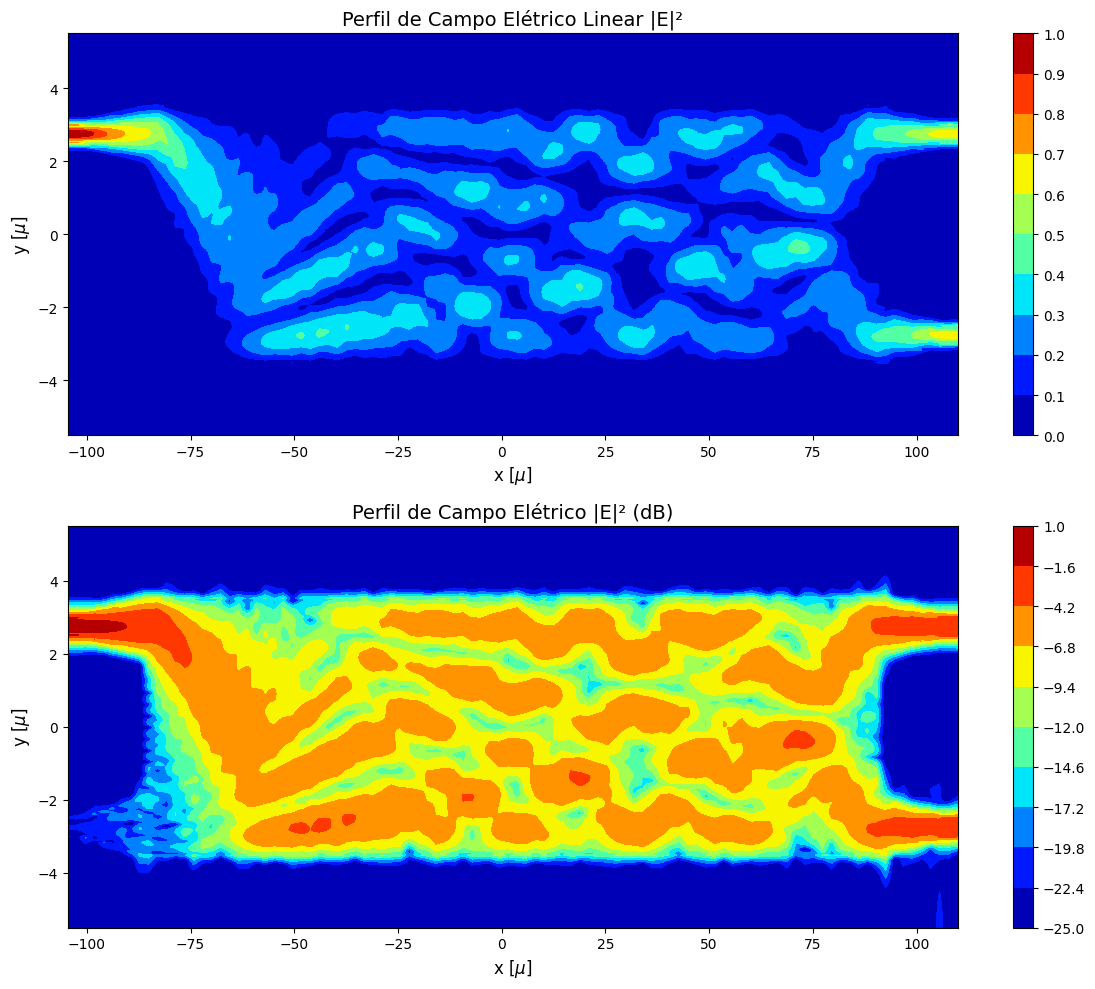

In [42]:
fig,axs = plt.subplots(2,1,figsize= (12,10))


mycmap1 = plt.get_cmap("jet")

v1 = np.linspace(0,1,11, endpoint=True)

cp1 = axs[0].contourf(x, y, np.clip(np.transpose(Emag[:,:,0]), v1.min(), v1.max()), v1, cmap = mycmap1)
plt.colorbar(cp1, ax=axs[0], ticks=v1)

axs[0].set_xlabel(r"x [$\mu$]", fontsize=12)
axs[0].set_ylabel(r"y [$\mu$]", fontsize=12)
axs[0].set_title("Perfil de Campo Elétrico Linear |E|²", fontsize = 14)

mycmap2 = plt.get_cmap("jet")

v2 = np.linspace(-25,1,11, endpoint=True)

cp2 = axs[1].contourf(x, y, np.clip(10*np.log10(np.transpose(Emag[:,:,0])), v2.min(), v2.max()), v2, cmap = mycmap2)
plt.colorbar(cp2, ax=axs[1], ticks=v2)

axs[1].set_xlabel(r"x [$\mu$]", fontsize=12)
axs[1].set_ylabel(r"y [$\mu$]", fontsize=12)
axs[1].set_title("Perfil de Campo Elétrico |E|² (dB)", fontsize = 14)

plt.tight_layout()
plt.savefig("2 Perfil de campo - otimizado - EME.png")
plt.show



In [43]:
emeApi.exportemesweep("MMI_EME_2x2_TE_177nm.dat", "Lumerical")

In [44]:
emeApi.close()